# K-Means

K-Means clustering on California housing features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

data_df = pd.read_csv("housing.csv")
data_df['total_bedrooms'] = data_df['total_bedrooms'].fillna(data_df['total_bedrooms'].median())
data_df = pd.get_dummies(data_df, columns=['ocean_proximity'], dtype=float)

target = data_df['median_house_value'].to_numpy()
raw_lon = data_df['longitude'].to_numpy()
raw_lat = data_df['latitude'].to_numpy()
X = data_df.drop(columns=['median_house_value']).to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X)

print(X.shape)

(20640, 13)


## Baseline (k=5)

Quick run with k=5 just to have something to look at before tuning.

In [2]:
km = KMeans(n_clusters=5, n_init=10, random_state=42)
labels = km.fit_predict(X)

print(f"Inertia: {km.inertia_:.2f}")
print(f"Silhouette: {silhouette_score(X, labels, sample_size=5000, random_state=42):.4f}")
print("Cluster sizes:", np.bincount(labels))

Inertia: 132964.82


Silhouette: 0.3633
Cluster sizes: [2579 6048 8500 1296 2217]


## Elbow and silhouette

Within-cluster sum of squares vs k (elbow plot), and silhouette score vs k. Elbow shows where adding clusters stops paying off, silhouette measures how well-separated the clusters actually are.

k=2  inertia=222520 silhouette=0.2267


k=3  inertia=182994 silhouette=0.2486


k=4  inertia=158186 silhouette=0.2986
k=5  inertia=132965 silhouette=0.3633


k=6  inertia=122177 silhouette=0.3618


k=7  inertia=101513 silhouette=0.3629


k=8  inertia=93119 silhouette=0.3281


k=9  inertia=84987 silhouette=0.3359


k=10 inertia=79473 silhouette=0.3488


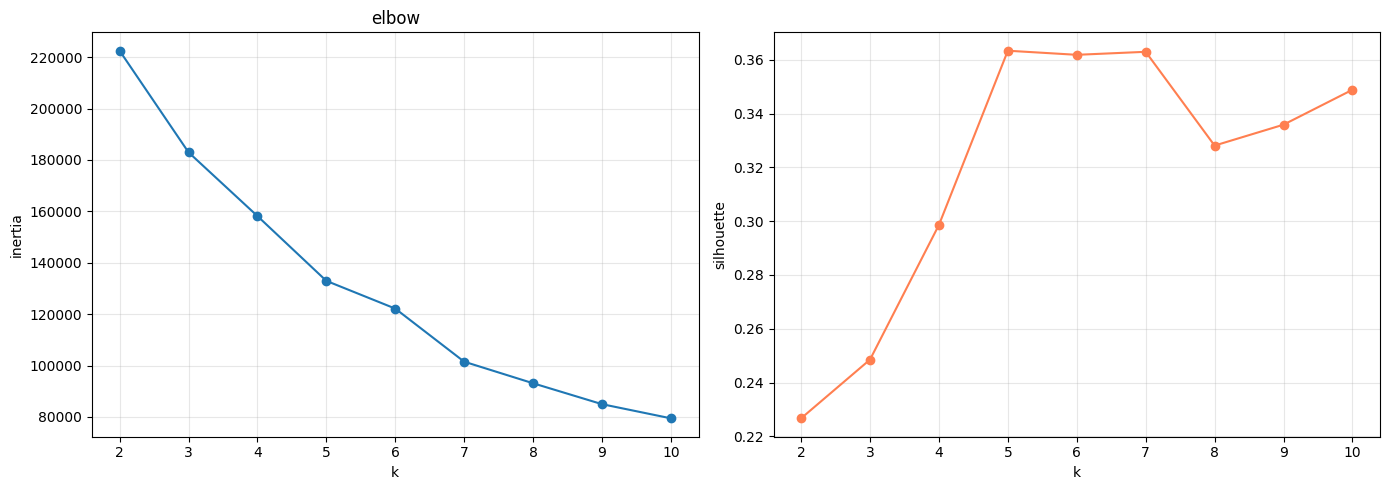

In [3]:
ks = list(range(2, 11))
inertias, sils = [], []

for k in ks:
    m = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(m.inertia_)
    sils.append(silhouette_score(X, m.labels_, sample_size=5000, random_state=42))
    print(f"k={k:<2} inertia={m.inertia_:.0f} silhouette={sils[-1]:.4f}")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(ks, inertias, 'o-')
axs[0].set_xlabel('k')
axs[0].set_ylabel('inertia')
axs[0].set_title('elbow')
axs[0].grid(alpha=0.3)

axs[1].plot(ks, sils, 'o-', color='coral')
axs[1].set_xlabel('k')
axs[1].set_ylabel('silhouette')
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## PCA projection of clusters

Project to 2D with PCA, color by cluster assignment. Shows whether the clusters separate cleanly in the dominant directions of variation.

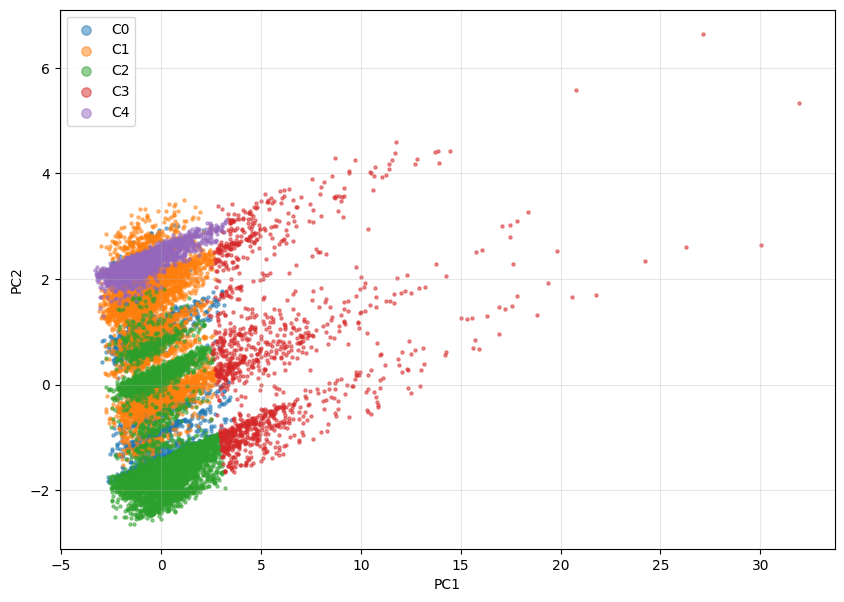

In [4]:
Z = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(10, 7))
for c in np.unique(labels):
    mask = labels == c
    plt.scatter(Z[mask, 0], Z[mask, 1], s=5, alpha=0.5, label=f'C{c}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=3)
plt.grid(alpha=0.3)
plt.show()

## Geographic view

Plot lat/long colored by cluster. Usually the cleanest view since California's housing has strong geographic structure.

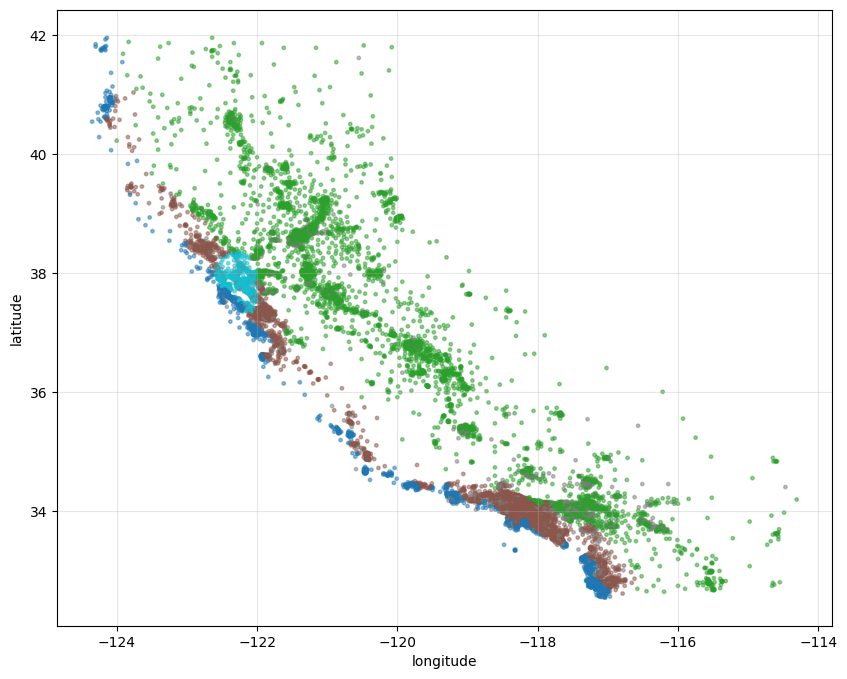

In [5]:
plt.figure(figsize=(10, 8))
plt.scatter(raw_lon, raw_lat, c=labels, cmap='tab10', s=6, alpha=0.5)
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.grid(alpha=0.3)
plt.show()

## Target vs cluster

Box plot of `median_house_value` per cluster. Target was held out during clustering — does the unsupervised structure line up with house value anyway?

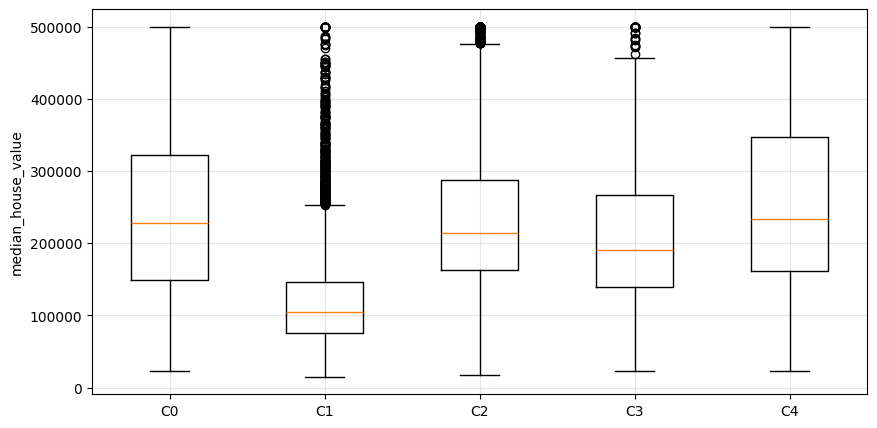

C0 n=2579   mean=248440 median=228500
C1 n=6048   mean=122823 median=105200
C2 n=8500   mean=239263 median=213700
C3 n=1296   mean=214123 median=191100
C4 n=2217   mean=259225 median=233100


In [6]:
plt.figure(figsize=(10, 5))
plt.boxplot([target[labels == c] for c in np.unique(labels)],
            tick_labels=[f'C{c}' for c in np.unique(labels)])
plt.ylabel('median_house_value')
plt.grid(alpha=0.3)
plt.show()

for c in np.unique(labels):
    vals = target[labels == c]
    print(f"C{c} n={len(vals):<6} mean={vals.mean():.0f} median={np.median(vals):.0f}")

## From-scratch K-Means

Init centroids, assign points to nearest, update centroids, repeat until stable. Matches `src/rice_ml/unsupervised_ml/kmeans.py`.

Scratch inertia: 21342.52
Iters: 14


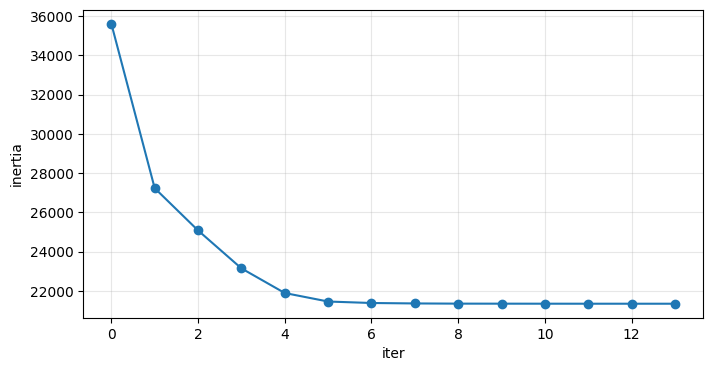

In [7]:
from rice_ml.unsupervised_ml import KMeans as KMeansScratch

rng = np.random.default_rng(42)
sub = rng.choice(len(X), 3000, replace=False)
scratch = KMeansScratch(k=5).fit(X[sub])
print(f"Scratch inertia: {scratch.inertia_:.2f}")
print(f"Iters: {len(scratch.inertia_history_)}")

plt.figure(figsize=(8, 4))
plt.plot(scratch.inertia_history_, 'o-')
plt.xlabel('iter')
plt.ylabel('inertia')
plt.grid(alpha=0.3)
plt.show()